In [55]:
import numpy as np

In [56]:
X=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]
)


#y=np.array([0,0,0,1])
#y=np.array([0,1,1,1])
y=np.array([0,1,1,0])

In [57]:
import matplotlib.pyplot as plt


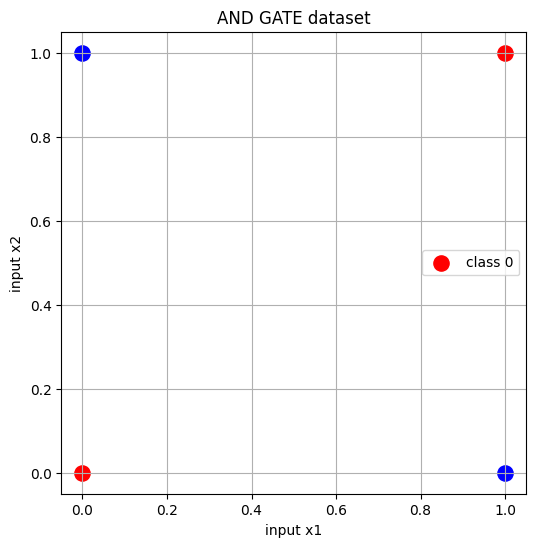

In [58]:
plt.figure(figsize=(6,6))
for i in range(len(X)):
    if y[i]==0:
        plt.scatter(X[i][0],X[i][1],color='red',s=120,label='class 0' if i==0 else "")
    else:
        plt.scatter(X[i][0],X[i][1],color='blue',s=120,label='class 1' if i==3 else "")

plt.xlabel("input x1")
plt.ylabel("input x2")
plt.title("AND GATE dataset")
plt.grid(True)
plt.legend()        

In [59]:
class perceptron:
    def __init__(self,learning_rate=0.1,epochs=20):
        self.lr=learning_rate
        self.epochs=epochs
        self.weights=None
        self.bias=None

    def activation(self,z):
        if z>=0:
            return 1
        else:
            return 0        

    def fit(self,X,y):
        samples,features=X.shape
        self.weights = np.zeros(features)
        self.bias = 0

            # ensure binary targets
        y = np.array([1 if val > 0 else 0 for val in y])
        for epoch in range(self.epochs):
            for i in range(samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                predicted=self.activation(linear_output)
                error=y[i]-predicted
                self.weights += self.lr * error * X[i]
                self.bias+=self.lr*error

    def predict(self,X):
        predictions=[]
        for x in X:
              z = np.dot(x, self.weights) + self.bias
              predictions.append(self.activation(z))
        return np.array(predictions)


In [60]:
model=perceptron(learning_rate=0.1,epochs=10)
model.fit(X,y)

In [61]:
predictions=model.predict(X)
print("\nFinal Prediction")
for i in range(len(X)):
    print(f"Input: {X[i]} Predicted Output: {predictions[i]} Actual Output: {y[i]}")


Final Prediction
Input: [0 0] Predicted Output: 1 Actual Output: 0
Input: [0 1] Predicted Output: 1 Actual Output: 1
Input: [1 0] Predicted Output: 0 Actual Output: 1
Input: [1 1] Predicted Output: 0 Actual Output: 0


In [62]:
print("\nFinal Weights and Bias")
print(f"Weights: {model.weights}")
print(f"Bias: {model.bias}")


Final Weights and Bias
Weights: [-0.1  0. ]
Bias: 0.0


D:\temp\ipykernel_20452\646990097.py:8: RuntimeWarning: divide by zero encountered in divide
  y_values=-(model.weights[0]*x_values+model.bias)/model.weights[1]


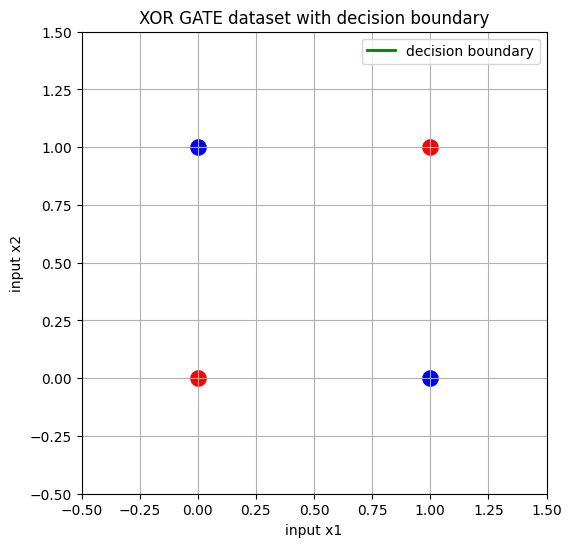

In [64]:
plt.figure(figsize=(6,6))
for i in range(len(X)):
    if y[i]==0:
        plt.scatter(X[i][0],X[i][1],color='red',s=120)
    else:
        plt.scatter(X[i][0],X[i][1],color='blue',s=120)
x_values=np.linspace(-0.5,1.5,100)
y_values=-(model.weights[0]*x_values+model.bias)/model.weights[1]
plt.plot(x_values,y_values,color='green',label='decision boundary',linewidth=2)
plt.xlim(-0.5,1.5)
plt.ylim(-0.5,1.5)
plt.xlabel("input x1")
plt.ylabel("input x2")
#plt.title("AND GATE dataset with decision boundary")
plt.title("XOR GATE dataset with decision boundary")
plt.grid(True)
plt.legend()
plt.show()        